# Fast post-adiabatic waveforms in FEW

In this tutorial we outline the basic features of the FEW implementation of 1PAT1R, a post-adiabatic self-force waveform model describing the quasicircular inspiral of a spinning secondary object (black hole or neutron star) into a slowly spinning Kerr black hole. Both spins are assumed to be aligned with the orbital angular momentum.

<br/>
We adopt the following notational conventions:

- The initial masses of the objects are denoted $m_1$ and $m_2$, with $m_1 > m_2$.

- The initial total mass is $M := m_1 + m_2$, and the symmetric mass ratio is $\nu := \frac{m_1m_2}{(m_1+m_2)^2}$.

- The initial dimensionless spin parameters of the two components are denoted $\chi_1$ and $\chi_2$.

- The orbital radius is parameterised by $p(t) := [M\Omega_{\rm phys}(t)]^{-2/3}$, where $\Omega_{\rm phys}(t)$ is the physical orbital frequency.


<br/>
<div style="margin-bottom: 1em;">

The model is subject to the following parameter restrictions:

</div>

|              | $m_2$      | $\chi_1$             | $\chi_2$                  | $p$                                                  |
|--------------|------------|----------------------|---------------------------|------------------------------------------------------|
| Allowed      | $(0, m_1]$ | $[-1, 1]$            | $[-1, 1]$                 | ${\rm max}(p_{\rm ISCO}+0.01, 6.26) \leq p \leq 30$  |
| Recommended  |     ---    | $\|\chi_1\| < 25\nu$ | $\|\chi_2\| \ll \nu^{-1}$ | $6 + 1.5\nu^{1/4} < p < 0.02\nu^{-2}$                |

where $p_{\rm ISCO}$ is the radius of the innermost stable circular orbit (divided by $m_1$) for a Kerr black hole of mass $m_1$ and dimensionless spin $\chi_1$. 



In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Waveform generation

### 1.1. Generic waveform interface

1PAT1R waveforms can be generated using the generic $\texttt{GenerateEMRIWaveform}$ waveform generator. For detector frame waveforms, a generator can be instantiated as follows:

In [ ]:
from few.waveform import GenerateEMRIWaveform

inspiral_kwargs = {}
amplitude_kwargs = {}

waveform_generator = GenerateEMRIWaveform(
        "Circ1PAT1R",
        #sum_kwargs = dict(pad_output=True), 
        inspiral_kwargs = inspiral_kwargs,
        amplitude_kwargs = amplitude_kwargs,
        frame = "detector"
    )

We now consider the system with the following parameters:

In [7]:
# Define parameters
m1 = 1e6        # primary mass [solar masses]
m2 = 10         # secondary mass [solar masses]
chi1  = 1e-5    # primary spin chi1 (dimensionless)
p0 = 9.0        # initial orbital separation [M]
chi2  = 0.1     # secondary spin

dL = 1.0        # luminosity distance [Gpc]
e0 = 0.0        # eccentricity
xI0 = 1.0       # cos(inclination)

qK = np.pi/3    # initial BH spin polar angle in ecliptic coords [rad]
phiK = np.pi/4  # initial BH spin azimuthal angle in ecliptic coords [rad]
qS = np.pi/5    # sky location polar angle in ecliptic coords [rad]
phiS = np.pi/3  # sky location azimuthal angle in ecliptic coords [rad]

Phi_phi0 = np.pi/4      # initial azimuthal phase [rad]
Phi_theta0 = np.pi/4    # initial polar phase [rad] (redundant for this model)
Phi_r0 = np.pi/4        # initial radial phase [rad] (redundant for this model)

dt = 5.         # time step for the returned waveform [s]
T  = 1          # total duration [yr]

params = [m1, m2, chi1, p0, e0, xI0, dL, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, chi2]

The waveform can be generated as follows.

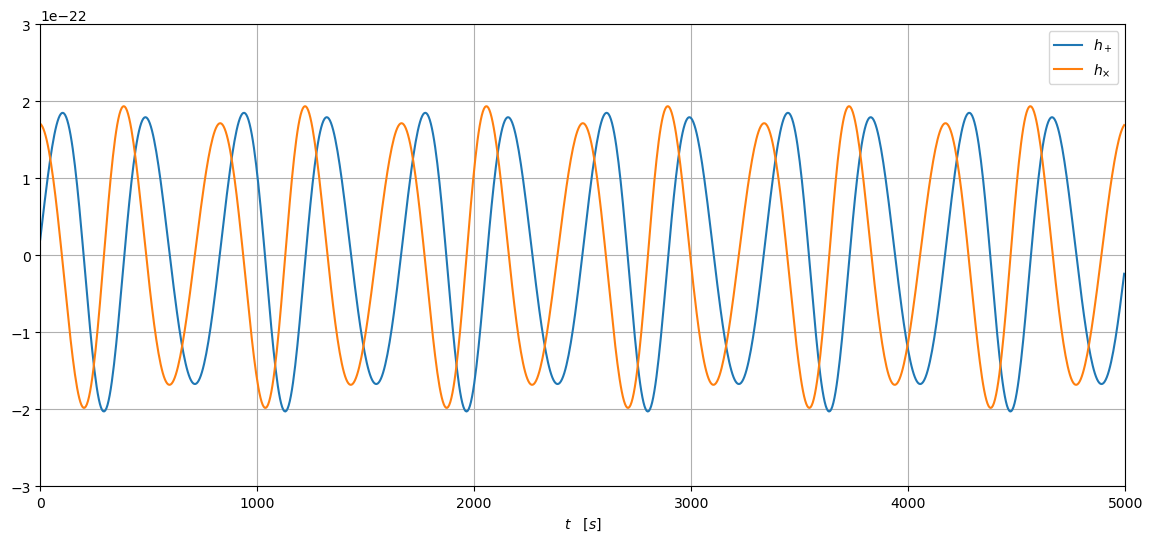

In [8]:
h = waveform_generator(*params, T=T, dt=dt)
time_array = np.arange(0, len(h)) * dt

plt.gcf().set_size_inches(14, 6)
plt.plot(time_array[:1000], h.real[:1000], label=r"$h_+$")
plt.plot(time_array[:1000], -h.imag[:1000], label=r"$h_{\times}$")
plt.xlim(0, 5000)
plt.ylim(-3e-22, 3e-22)
plt.xlabel(r"$t \quad [s]$")
plt.legend()
plt.grid()

### 1.2. Waveform class

One can directly instantiate a 1PAT1R waveform generator object:

In [9]:
from few.waveform import Circ1PAT1R

WF1PAT1R = Circ1PAT1R()

To generate a source-frame waveform with given parameters, simply call

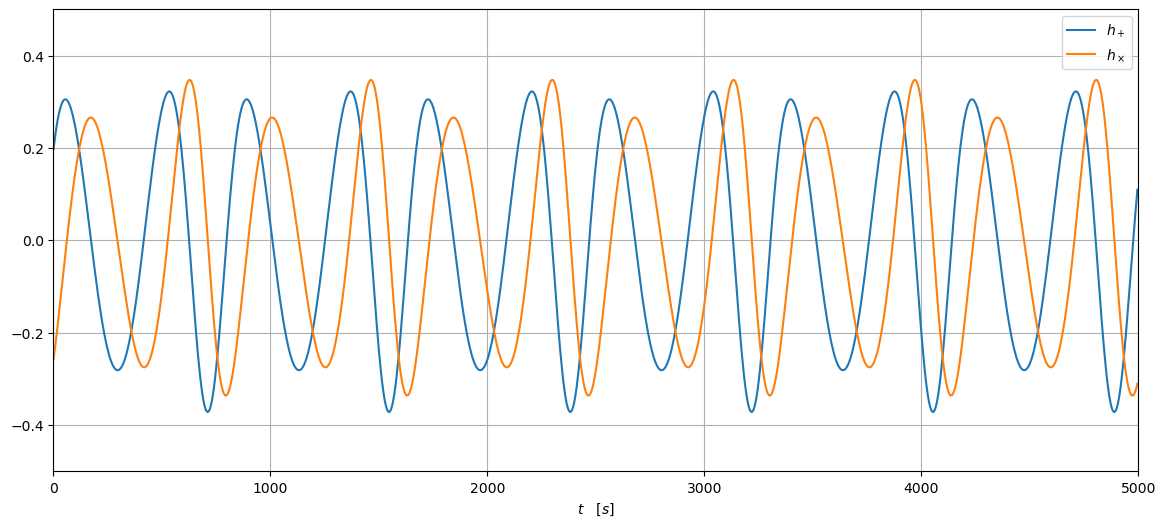

In [10]:
theta = phi = np.pi/4 # polar and azimuthal viewing angles [rad]
h_src = WF1PAT1R(m1, m2, chi1, p0, theta, phi, chi2, dt=dt, T=T)
time_array = dt*np.arange(0, len(h_src))

plt.gcf().set_size_inches(14, 6)
plt.plot(time_array[:1000], h_src[:1000].real,  label=r"$h_+$")
plt.plot(time_array[:1000],-h_src[:1000].imag,  label=r"$h_\times$")
plt.ylim(-0.5, 0.5)
plt.xlim(0, 5000)
plt.xlabel(r"$t \quad[s]$")
plt.legend()
plt.grid()

## 2. Post-adiabatic trajectories

In [11]:
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.circ1pat1r import TrajectoryCirc1PAT1R

In this section we describe the implementation of the post-adiabatic trajectory. We highlight the following features:


- The model incorporates the evolution of the primary black hole's mass due to the emission of gravitational radiation. Internally this is described using the mass deviation parameter 
  $$
      \delta M(t) := \frac{m_1^{\rm phys}(t) - m_1}{\nu M}, \qquad\qquad (2.1)
  $$
  where $m_1^{\rm phys}(t)$ is the time-varying physical mass of the primary black hole. 

- The model additionally incorporates the evolution of the primary black hole's spin, but the secondary object's spin is treated as fixed. Internally, we make use of the rescaled variables $\tilde \chi_1$ and $\tilde \chi_2$ defined by
  $$
      \tilde\chi_1 := \frac{m_1}{M}\chi_1 = \frac{1}{2}(1+\sqrt{1-4\nu})\chi_1, \qquad\tilde\chi_2 := \frac{m_2}{M}\chi_2 = \frac{1}{2}(1-\sqrt{1-4\nu})\chi_2. \qquad\qquad (2.2)
  $$
  The evolution of the primary spin is then described using the parameter $\delta\tilde\chi_1(t) := \tilde\chi_1(t) - \tilde\chi_1(t=0)$.

Altogether the trajectory state vector for this model is $\vec y = (p, e, x_I, \Phi_\phi, \Phi_\theta, \Phi_r, \delta M, \delta\tilde\chi_1)$, where the first 6 elements are the same as for the adiabatic order models included in FEW. 

The system of ODEs describing the time-evolution of the state vector is defined using the $\texttt{TrajectoryCirc1PAT1R}$ class. These differential equations can be integrated using the generic $\texttt{EMRIInspiral}$ solver:

In [ ]:
# Instantiate integrator
traj = EMRIInspiral(func=TrajectoryCirc1PAT1R)

# System parameters
m1 = 1e6       # primary mass [solar masses]
m2 = 1e6       # secondary mass [solar masses]
a  = -0.2       # primary spin chi1 (dimensionless)
chi2  = -0.1   # secondary spin
p0 = 15.0      # initial orbital separation [M]
dt = 1.   # time step [s]
T  = 1    # total duration [yr]

# Integrate
t, p, e, x, Phi_phi, Phi_theta, Phi_r, deltaM, deltachit1 = traj( 
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    chi2,
    T=T
)

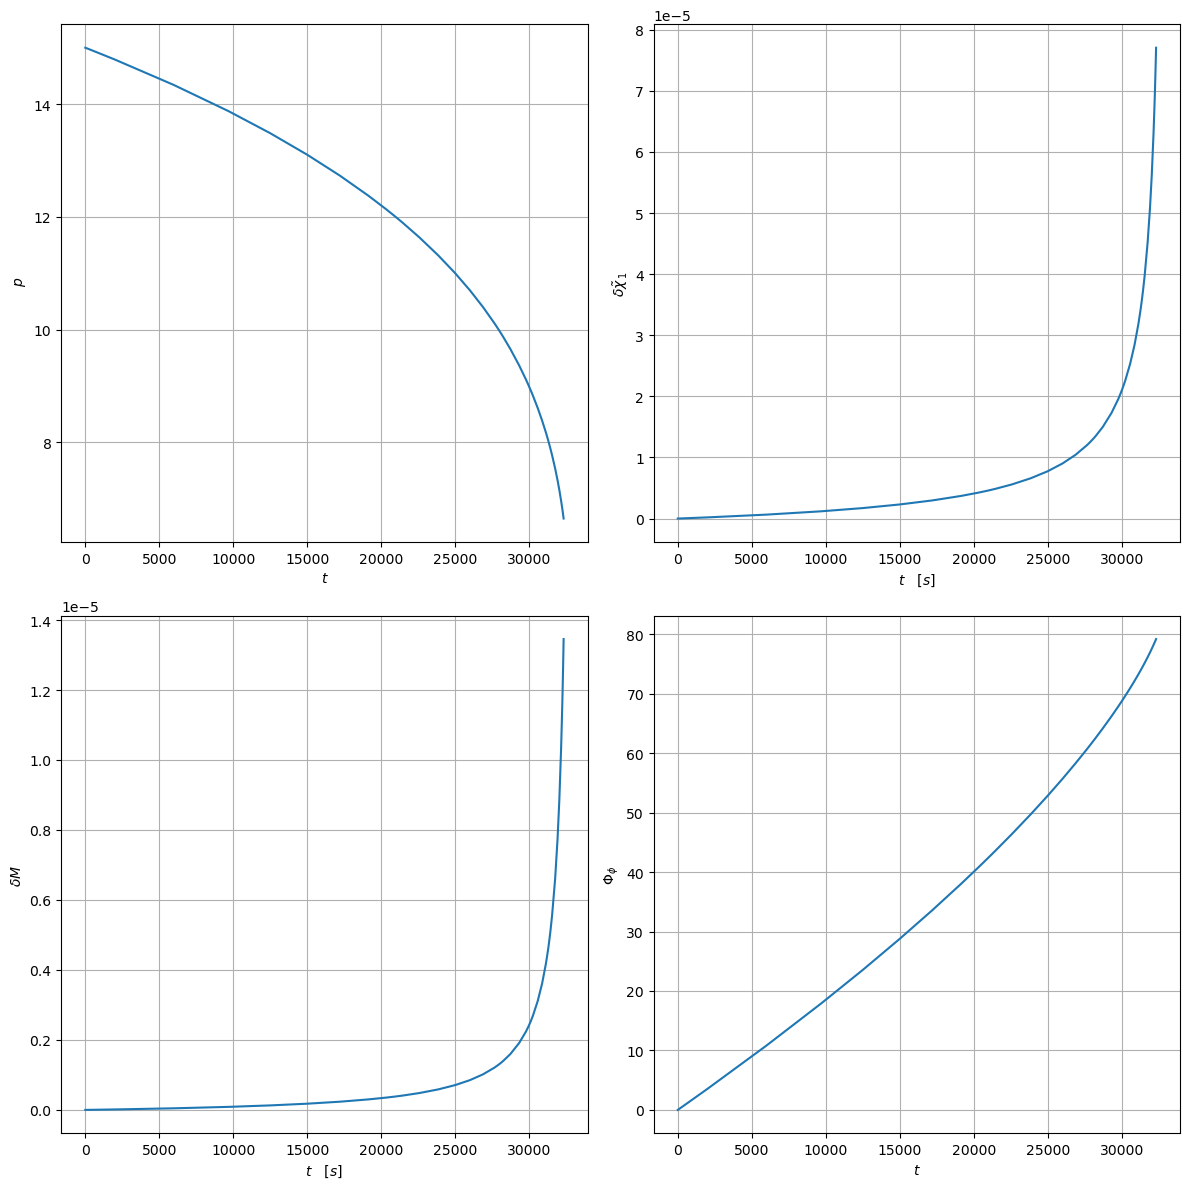

In [13]:
plt.gcf().set_size_inches(12, 12)
plt.subplot(221)
plt.plot(t, p)
plt.xlabel(r"$t$")
plt.ylabel(r" $p$")
plt.grid()

plt.subplot(222)
plt.plot(t, deltachit1)
plt.xlabel(r"$t \quad [s]$")
plt.ylabel(r"$\delta\tilde\chi_1$")
plt.grid()

plt.subplot(223)
plt.plot(t, deltaM)
plt.xlabel(r"$t \quad [s]$")
plt.ylabel(r"$\delta M$")
plt.grid()

plt.subplot(224)
plt.plot(t, Phi_phi)
plt.xlabel(r"$t$")
plt.ylabel(r"$\Phi_\phi$")
plt.grid()

plt.gcf().tight_layout()

Note that the trajectory evolves the parameters $\delta M$ and $\delta \tilde\chi_1$ by default. This can be switched off by setting $\texttt{evolve\_primary = False}$ when creating the trajectory (it can also be set as through `inspiral_kwargs` in `GenerateEMRIWaveform`)

In [14]:
traj_no_evolve_primary = EMRIInspiral(func=TrajectoryCirc1PAT1R, evolve_primary=False)

t_2, p_2, e_2, x_2, Phi_phi_2, Phi_theta_2, Phi_r_2, deltaM_2, deltachit1_2 = traj_no_evolve_primary( 
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    chi2,
    T=T
)

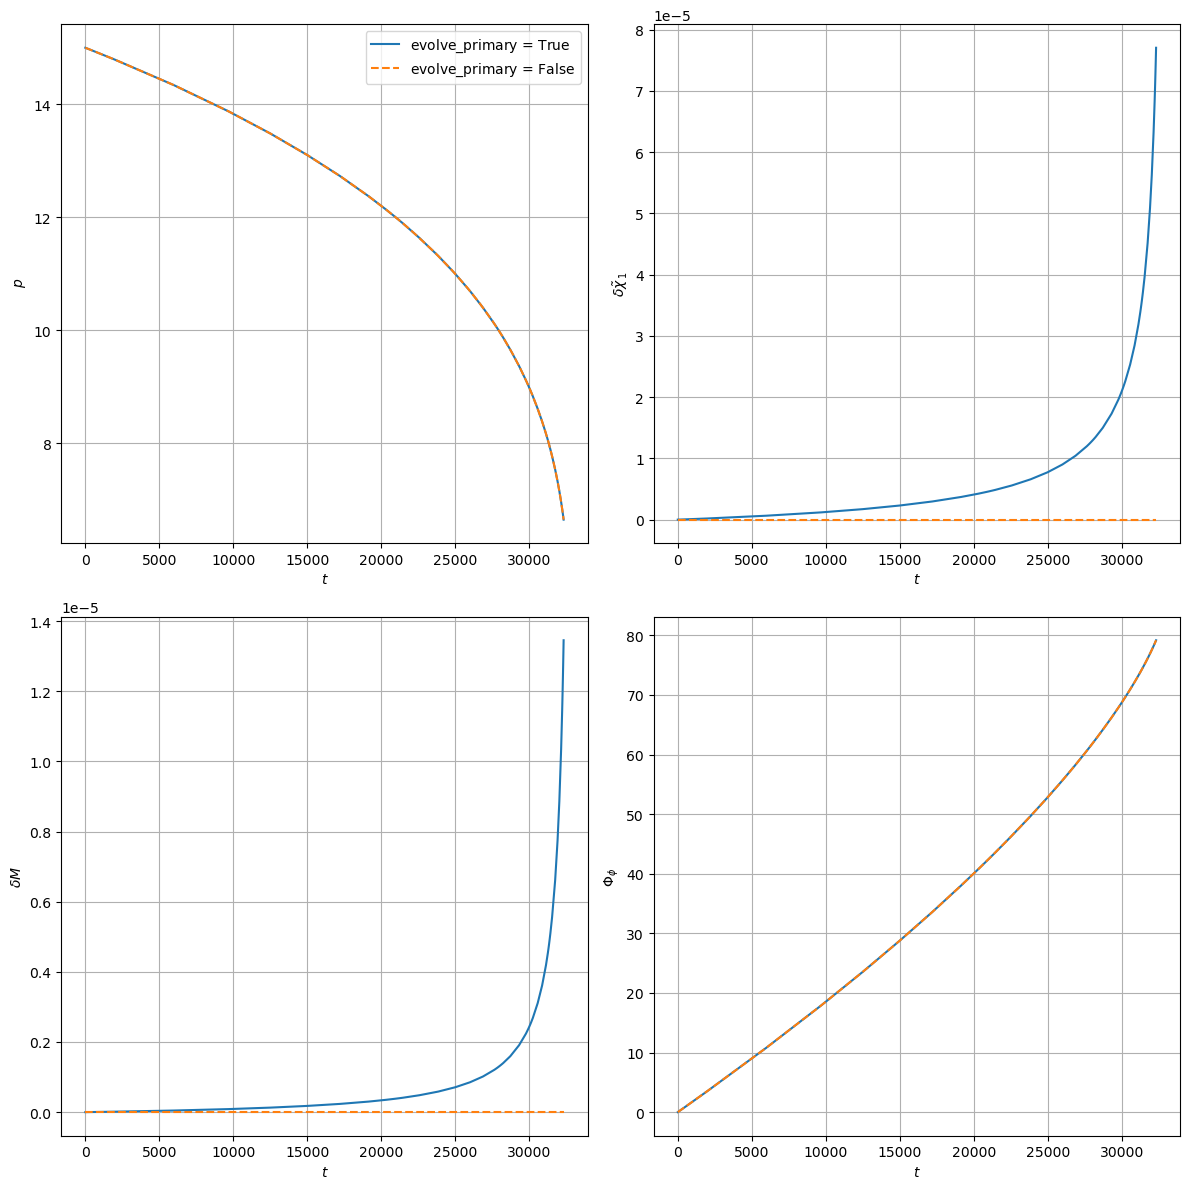

In [15]:
plt.gcf().set_size_inches(12, 12)
plt.subplot(221)
plt.plot(t, p, label=r"$\text{evolve\_primary = True}$")
plt.plot(t_2, p_2, ls='--', label=r"$\text{evolve\_primary = False}$")
plt.xlabel(r"$t$")
plt.ylabel(r" $p$")
plt.grid()
plt.legend()

plt.subplot(222)
plt.plot(t, deltachit1, label=r"$\text{evolve\_primary = True}$")
plt.plot(t_2, deltachit1_2, ls='--', label=r"$\text{evolve\_primary = False}$")
plt.xlabel(r"$t$")
plt.ylabel(r"$\delta\tilde\chi_1$")
plt.grid()

plt.subplot(223)
plt.plot(t, deltaM, label=r"$\text{evolve\_primary = True}$")
plt.plot(t_2, deltaM_2, ls='--', label=r"$\text{evolve\_primary = False}$")
plt.xlabel(r"$t$")
plt.ylabel(r"$\delta M$")
plt.grid()

plt.subplot(224)
plt.plot(t, Phi_phi, label=r"$\text{evolve\_primary = True}$")
plt.plot(t_2, Phi_phi_2, ls='--', label=r"$\text{evolve\_primary = False}$")
plt.xlabel(r"$t$")
plt.ylabel(r"$\Phi_\phi$")
plt.grid()

plt.gcf().tight_layout()

## 3. Post-adiabatic waveform amplitudes

In [16]:
from few.amplitude.ampinterp1d import AmplitudeCirc1PAT1R

The full waveform mode amplitude $\mathcal{A}_{\ell m}$ in 1PAT1R is given by

$$
    \mathcal{A}_{\ell m}(p, \nu, \delta M, \tilde\chi_1, \tilde\chi_2) = \Delta_m(\nu)\left[\mathcal{A}_{\ell m}^{\rm 0PA}(p) + \nu\bar{\mathcal{A}}_{\ell m}^{\rm 1PA}(p) + \tilde\chi_1\mathcal{A}_{\ell m}^{\rm 1PA\chi_1}(p) + \tilde\chi_2\mathcal{A}_{\ell m}^{\rm 1PA\chi_2}(p) + \nu\delta M\mathcal{A}_{\ell m}^{\rm 1PA\delta M}(p)\right], \qquad\qquad (3.1)
$$

where $\mathcal{A}_{\ell m}^{\rm 0PA}$ and $\nu\bar{\mathcal{A}}_{\ell m}^{\rm 1PA}$ are the non-spinning 0PA and 1PA self-force amplitudes, $\tilde\chi_1\mathcal{A}_{\ell m}^{\rm 1PA\chi_1}$ and $\tilde\chi_2\mathcal{A}_{\ell m}^{\rm 1PA\chi_2}$ are the corrections due to the primary and secondary spin, respectively, and $\nu\delta M\mathcal{A}_{\ell m}^{\rm 1PA\delta m_1}$ is a correction due to the evolution of the mass of the primary black hole. The factor $\Delta_m(\nu)$ is defined 
$$
    \Delta_m(\nu) := \begin{cases}1 & \text{for even }m\\
                    \sqrt{1-4\nu} & \text{for odd }m.
                    \end{cases}
$$

The generation of the waveform mode amplitudes is handled by an instance of the $\texttt{AmplitudeCirc1PAT1R}$ class:

In [17]:
amp = AmplitudeCirc1PAT1R()

We can generate a single piece $\mathcal{A}_{\ell m}^{\rm 0PA}$, $\bar{\mathcal{A}}_{\ell m}^{\rm 1PA}$ $\mathcal{A}_{\ell m}^{\rm 1PA\chi_1}$, $\mathcal{A}_{\ell m}^{\rm 1PA\chi_2}$ or $\mathcal{A}_{\ell m}^{\rm 1PA\delta M}$ using the $\texttt{get\_amplitudes\_single\_piece}$ method, specifying the desired component using the $\texttt{data\_key}$ keyword argument:

In [26]:
# Orbital parameters
p = 8.0

amp_dict = {}
all_keys = ["0PA", "1PA", "1PAchi1", "1PAchi2", "1PAdeltam"]

for key in all_keys:
    amp_dict[key] = amp.get_amplitudes_single_piece(p, data_key=key)

$\texttt{get\_amplitudes\_single\_piece}$ returns the amplitude for each $(\ell, m)$ mode included in the model. To extract a single mode, we use the $\texttt{special\_index\_map}$ to extract the index corresponding to the given $(\ell, m)$ mode. For example, for the $(2,2)$ mode:

In [27]:
idx22 = amp.special_index_map[(2,2,0,0)] #k=n=0 for this circular, equatorial model

for key in all_keys:
    print(f"{key}:\t", amp_dict[key][0, idx22])

0PA:	 (0.6946048861679467-0.21844272921612304j)
1PA:	 (-0.022851570789984742-0.265245880401643j)
1PAchi1:	 (-0.07278410083578853+0.019489066890523387j)
1PAchi2:	 (-0.027089998775100977+0.008520210527706665j)
1PAdeltam:	 (0.4596143693643022-0.21895340463294682j)


To obtain the full summed amplitude using Eq. (3.1), use the $\texttt{get\_amplitudes}$ method. Note the value of $a$ in the below call is again redundant, and we instead pass the values of $\tilde \chi_{1,2}$:

In [28]:
nu=0.1
chit2=0.4
deltaM=0.1
chit1=0.11

combined_amps = amp.get_amplitudes(a, p, e, xI, nu, chit1, chit2, deltaM)
print("***** The (2,2) mode amplitude is: ", combined_amps[:, idx22][0], " *****")

***** The (2,2) mode amplitude is:  (0.6780736221806141-0.24160496973357656j)  *****


The 1PA terms in Eq. (3.1) can be omitted by setting the keyword argument $\texttt{zero\_PA\_amps\_only=True}$:

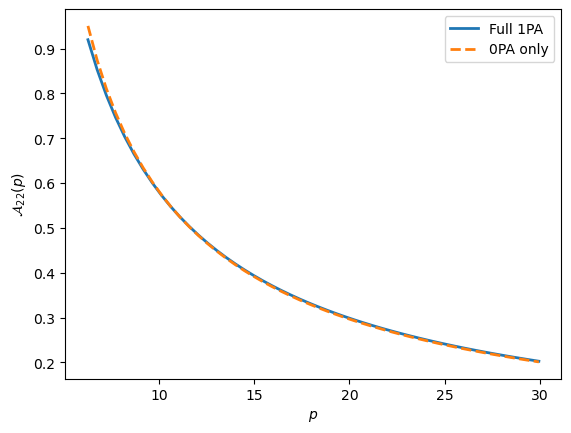

In [29]:
amp0PA = AmplitudeCirc1PAT1R(zero_PA_amps_only=True)
p_arr = np.linspace(6.26, 29.95)
amp22_arr = amp.get_amplitudes(a, p_arr, e, xI, nu, chit1, chit2, deltaM)[:, idx22]
amp22_0PA_arr = amp0PA.get_amplitudes(a, p_arr, e, xI, nu, chit1, chit2, deltaM)[:, idx22]

plt.plot(p_arr, np.abs(amp22_arr), lw=2.0, label="Full 1PA")
plt.plot(p_arr, np.abs(amp22_0PA_arr), lw=2.0, ls="--", label="0PA only")
plt.legend();
plt.xlabel(r"$p$");
plt.ylabel(r"$\mathcal{A}_{22}(p)$");

## 4. Advanced waveform options

The 1PA contributions to the amplitudes and the evolution of the primary mass and spin can both be disabled in the waveform generator using suitable keyword arguments:

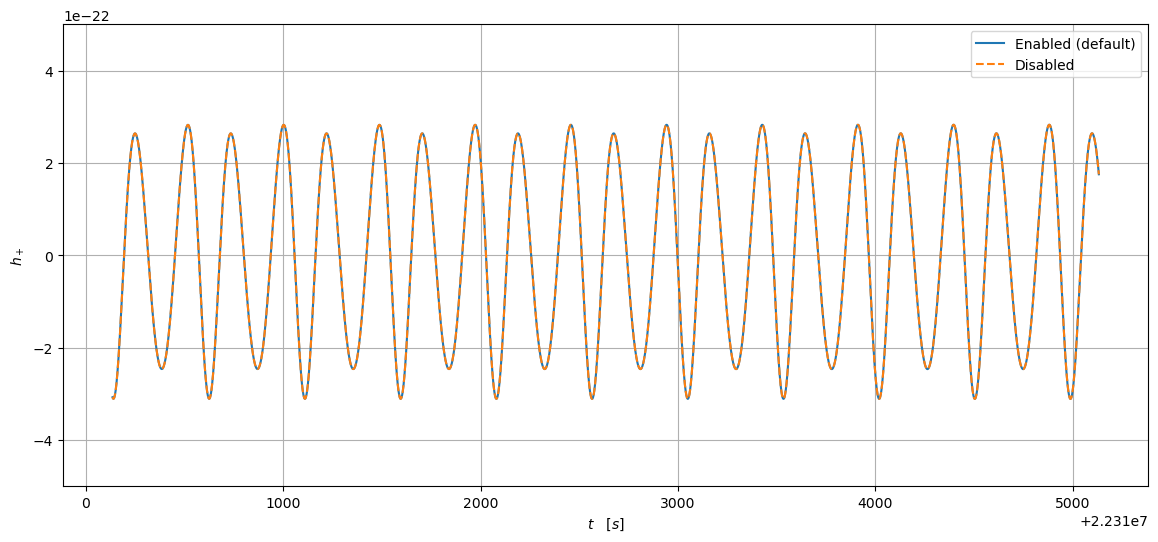

In [31]:
waveform_generator_off = GenerateEMRIWaveform(
        "Circ1PAT1R",
        #sum_kwargs = dict(pad_output=True), 
        inspiral_kwargs = {"evolve_primary": False},
        amplitude_kwargs = {"zero_PA_amps_only": True},
        frame = "detector"
    )
h_on = waveform_generator(*params, T=T, dt=dt)  #default behaviour
h_off = waveform_generator_off(*params, T=T, dt=dt)

plt.gcf().set_size_inches(14, 6)
plt.plot(dt*np.arange(len(h_on))[-5000:], h_on.real[-5000:], label="Enabled (default)")
plt.plot(dt*np.arange(len(h_off))[-5000:], h_off.real[-5000:], ls='--', label="Disabled")
plt.ylim(-5e-22, 5e-22)
plt.ylabel(r"$h_+$")
plt.xlabel(r"$t \quad [s]$")
plt.legend()
plt.grid()

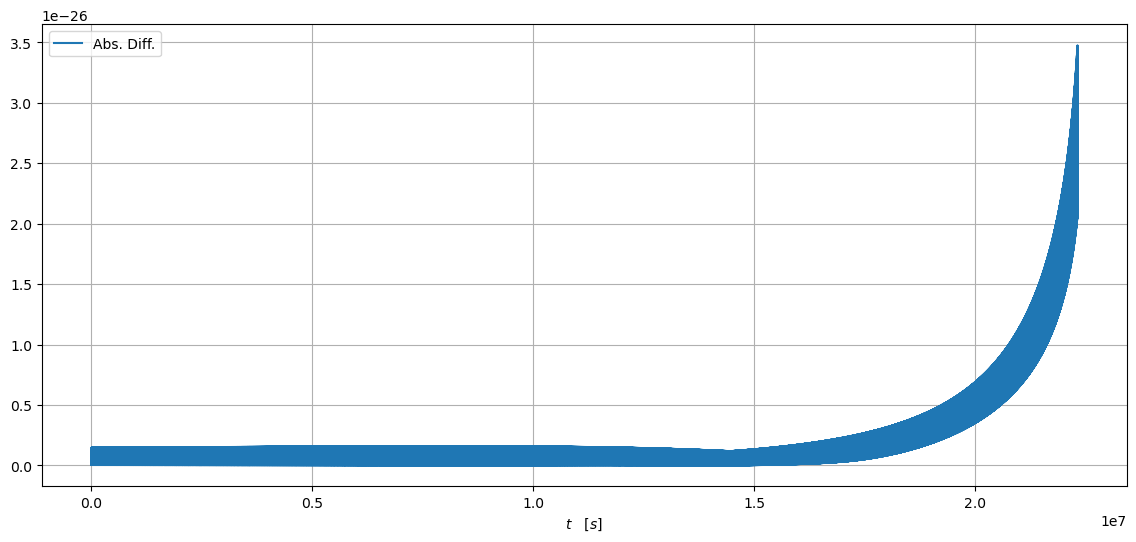

In [32]:
plt.gcf().set_size_inches(14, 6)
plt.plot(dt*np.arange(len(h_on)), np.abs(h_on - h_off), label="Abs. Diff.")
plt.legend(loc="upper left")
plt.xlabel(r"$t \quad [s]$")
plt.grid()